## 1️. 이미지에서 특징 추출 및 Stack

In [50]:

import cv2
import numpy as np
import os

# ORB (Oriented FAST and Rotated BRIEF) 특징 추출기 사용
# ORB는 SIFT와 SURF의 대안으로, 빠르고 효율적이며, OpenCV에서 무료로 사용 가능
def extract_orb_features_with_keypoints(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(img, None)
    return keypoints, descriptors

# 각 이미지에서 특징을 추출하고, 특징과 이미지 경로를 저장하는 함수
def extract_descritpors_from_folder(folder_path):
    descriptor_list = []
    keypoints_list = []
    image_paths = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path): continue

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            kps, descs = extract_orb_features_with_keypoints(img_path)
            if descs is not None:
                descriptor_list.append(descs)
                keypoints_list.append(kps)
                image_paths.append((img_path, class_name))

    return descriptor_list, keypoints_list, image_paths

train_descriptors, train_keypoints, train_paths = extract_descritpors_from_folder("train")
print(f"총 {len(train_descriptors)}개의 이미지에서 특징을 추출했습니다.")


총 120개의 이미지에서 특징을 추출했습니다.


## 2️. KMeans로 Visual Vocabulary 생성

In [51]:

# 모든 train image descriptor를을 하나의 배열로 결합
all_descriptors = np.vstack(train_descriptors)

# 클러스터 개수 (변경 가능)
num_clusters = 100

# # KMeans 클러스터링
def k_means(X, k, max_iters=1000):
    # 1. 초기 중심점 선택
    centers = X[np.random.choice(len(X), k, replace=False)]

    # TODO: 클러스터링 알고리즘 구현
    tol = 1e-4 #허용 오차 범위, 중심 이동이 이 이하로 작아지면 반복 중단하기 위함(너무 작은 움직임=거의 근접했다는 뜻)
    #max_iter번 반복
    for i in range(max_iters):
        #각 점들과 중심간의 거리 제곱 계산
        #X[:, np.newaxis, :] = [N, 1, D], centers[np.newaxis, :, :] = [1, k, D]
        #두 배열의 차이를 계산하면 [N, k, D] 모양의 차이를 가지는 벡터가 생성됨
        #N = 데이터 개수, k = 클러스터의 개수, D = 차이값 저장
        dist = (X[:, np.newaxis, :]-centers[np.newaxis, :, :])**2
        #차원에 따라 제곱합의 루트를 씌워 거리 계산
        dist = np.sqrt(np.sum(dist, axis=2))
        #각 데이터 샘플이 가장 가까운 중심 인덱스에 저장, 길이는 N
        labels = np.argmin(dist, axis=1)
        new_centers = np.zeros_like(centers)
        for j in range(k): #각 클러스터에 대해 반복
            pts = X[labels == j] #j번 클러스터에 할당된 데이터 포인트들만 추출
            if len(pts) > 0:
                #클러스터들의 평균으로 중심 업데이트
                new_centers[j] = pts.mean(axis=0) 
            else:
                new_centers[j] = centers[j]
        #중심 이동이 tol이하면 수렴했다는 뜻, 반복 종료
        if np.allclose(centers, new_centers, atol=tol):
            break

        centers = new_centers


    return labels, centers

labels, centers = k_means(all_descriptors, num_clusters)
print("클러스터 학습 완료")


클러스터 학습 완료


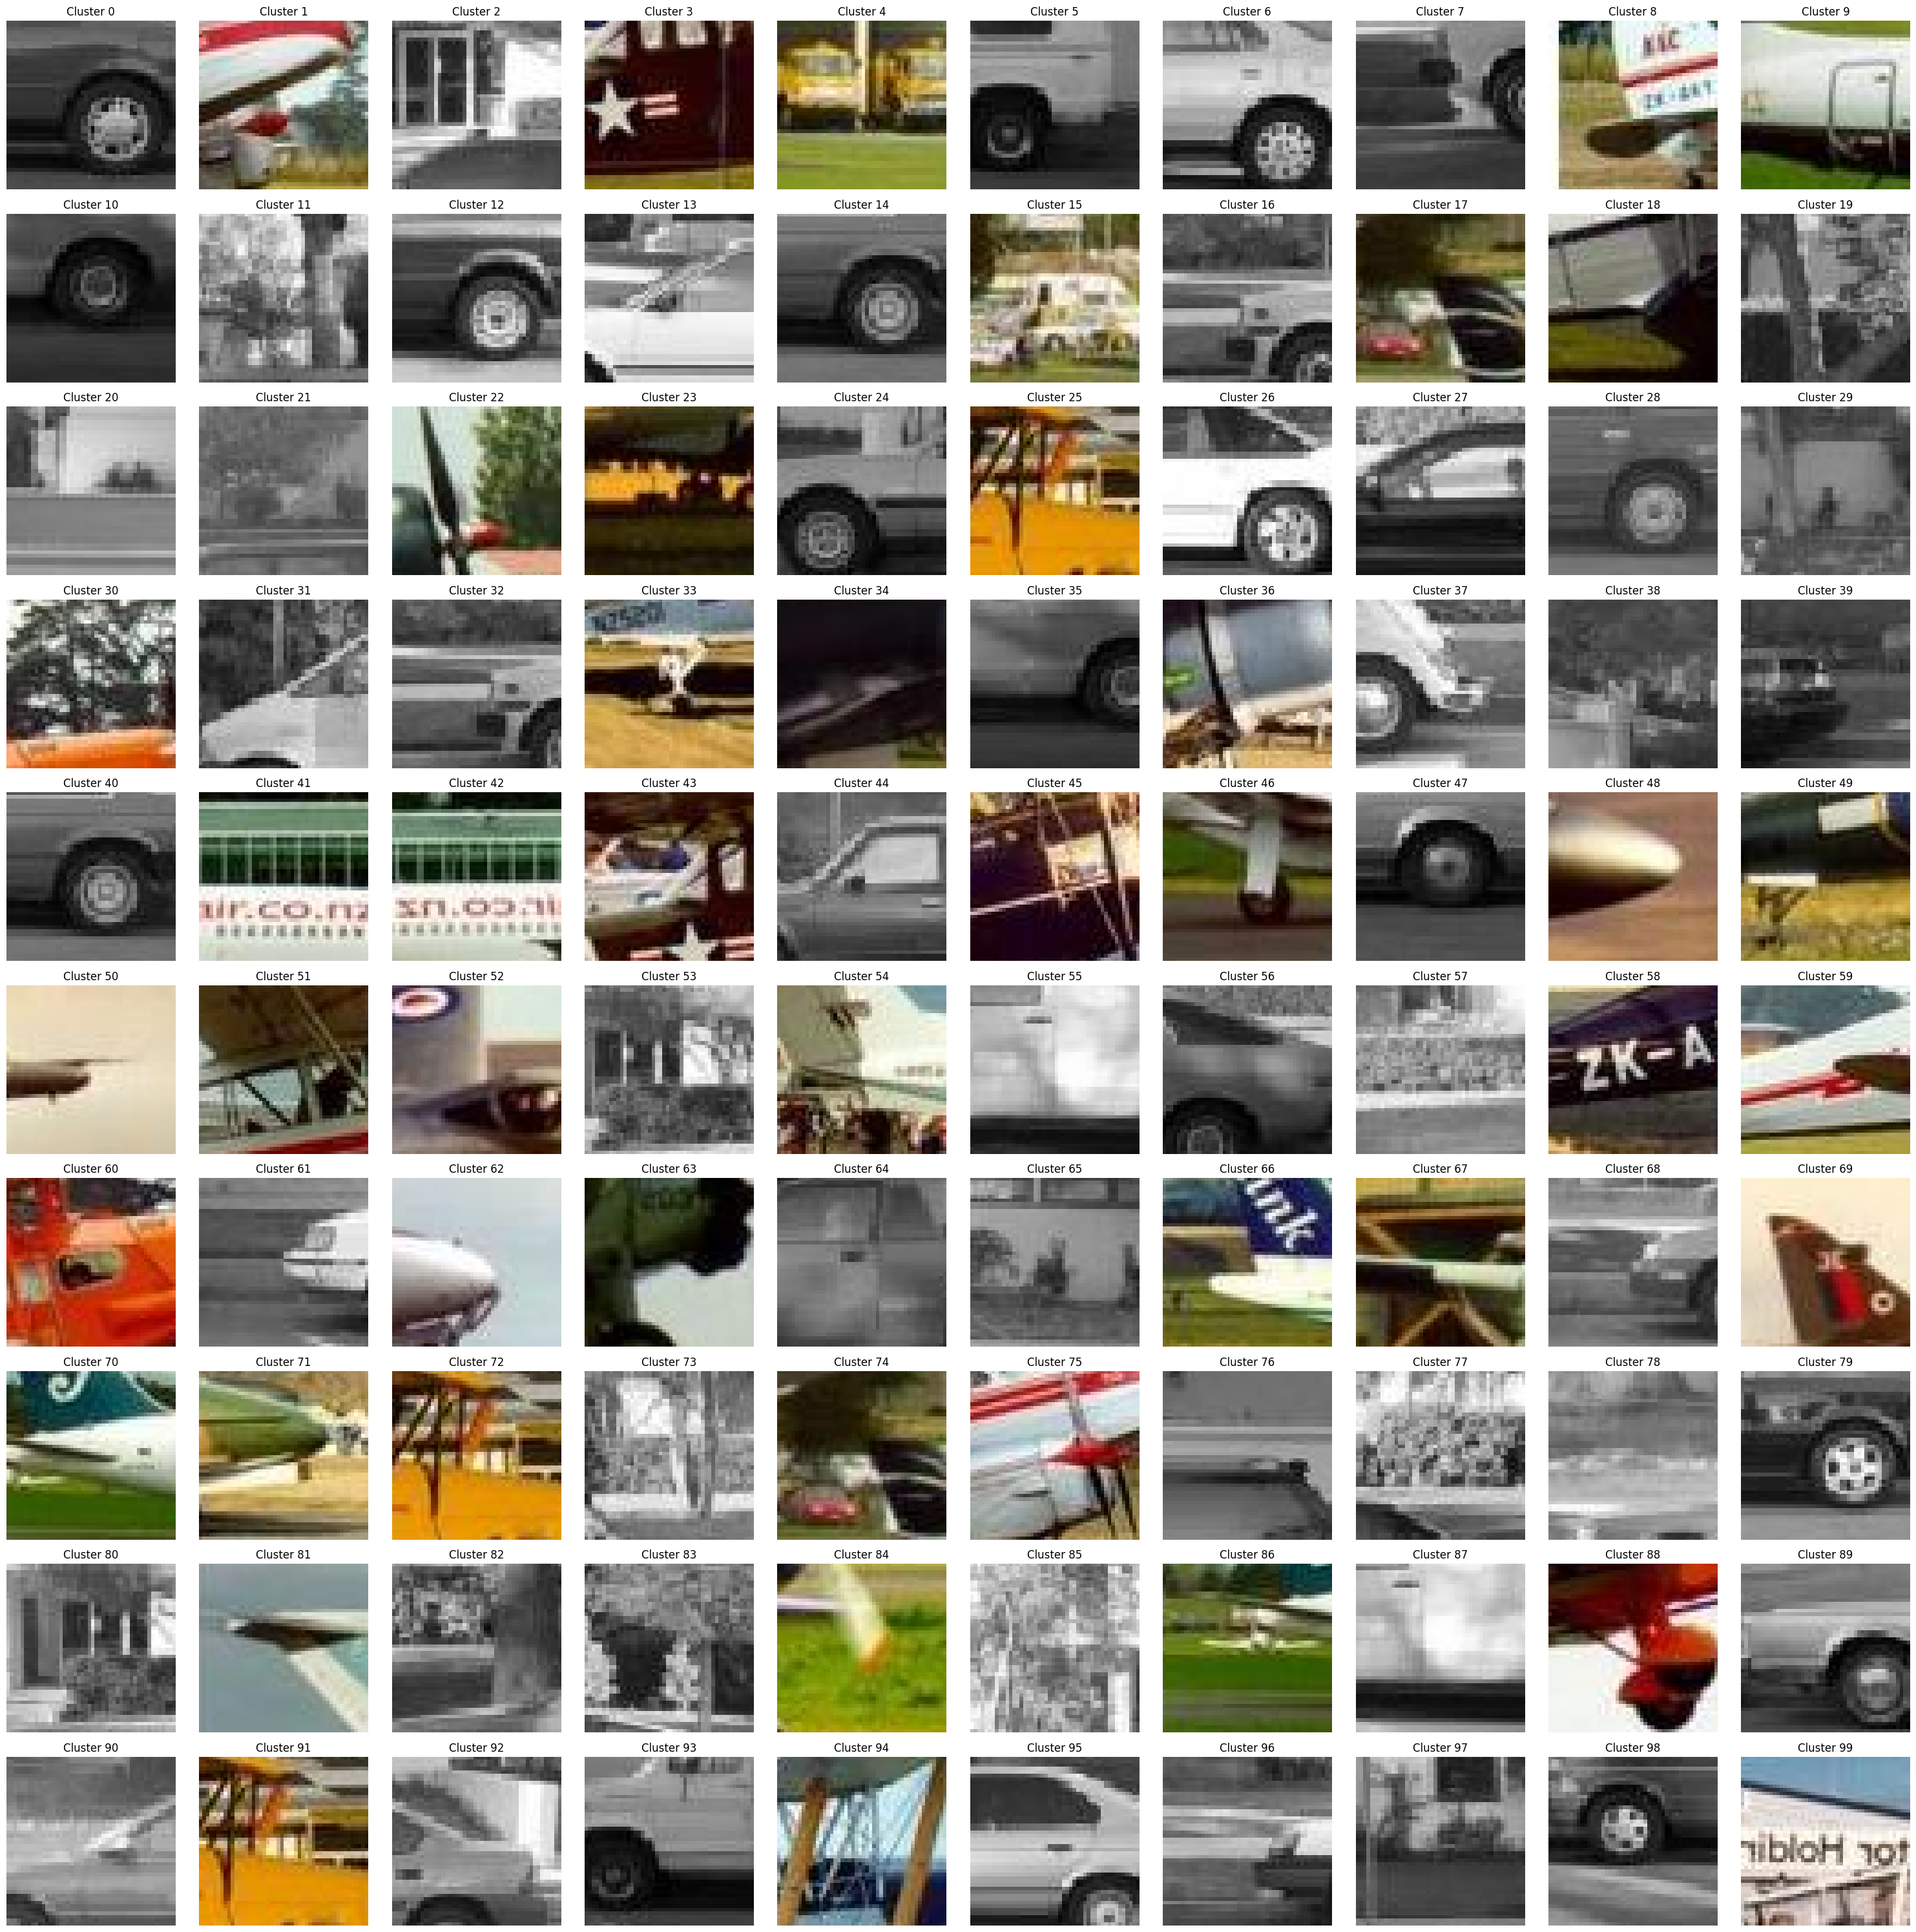

In [52]:
import matplotlib.pyplot as plt
import math

# cluster를 대표하는 이미지 패치 시각화
def visualize_cluster_representatives(descriptors, image_paths, keypointss, centers, cluster_num=10, patch_size=24):
    closest_dists = [np.inf] * cluster_num
    closest_imgs = [None] * cluster_num
    closest_pts = [None] * cluster_num

    for i, descriptors in enumerate(descriptors):
        if descriptors is None:
            continue
        img = cv2.imread(image_paths[i][0])
        keypoints = keypointss[i]

        for j, desc in enumerate(descriptors):
            distances = np.linalg.norm(centers - desc, axis=1)
            closest = np.argmin(distances)
            dist = distances[closest]

            if dist < closest_dists[closest]:
                closest_dists[closest] = dist
                closest_imgs[closest] = img
                if keypoints:
                    pt = keypoints[j].pt
                    closest_pts[closest] = (int(pt[0]), int(pt[1]))

    # 자동으로 행, 열 설정
    cols = math.ceil(math.sqrt(cluster_num))
    rows = math.ceil(cluster_num / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    for i in range(cluster_num):
        row, col = divmod(i, cols)
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.axis('off')
        if closest_imgs[i] is not None and closest_pts[i] is not None:
            x, y = closest_pts[i]
            patch = closest_imgs[i][max(y-patch_size,0):y+patch_size, max(x-patch_size,0):x+patch_size]
            if patch.size > 0:
                ax.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
                ax.set_title(f"Cluster {i}")
        else:
            ax.set_title(f"Cluster {i} (N/A)")
    plt.tight_layout()
    plt.show()


visualize_cluster_representatives(train_descriptors, train_paths, train_keypoints, centers, cluster_num=num_clusters)


## 3️. 이미지마다 Bag-of-Visual-Words Histogram 생성

In [53]:
# 히스토그램 생성
# 각 이미지에 대해 클러스터 중심과의 거리를 계산하여 가장 가까운 클러스터를 찾고, 해당 클러스터의 카운트를 증가시킴
def create_histogram(descriptors, centers):
    # TODO: 각 이미지에 대한 히스토그램 생성
    k = centers.shape[0] #클러스터의 개수 k 구하기
    histogram = np.zeros(k, dtype=int) #k길이의 histogram 생성

    #descriptor가 없는 경우
    if descriptors is None or len(descriptors) == 0: 
        return histogram
    
    #각 descriptor와 중심 간 차이 벡터 계산, [N, K, D] 벡터가 결과로 나옴
    dif = descriptors[:, None, :] - centers[None, :, :]
    #각 차이의 제곱합 -> 루트 = 거리 행렬 생성
    dist = np.sqrt(np.sum(dif**2, axis=2))
    #각 descriptor에 대해 가장 가까운 클러스터 label 선택
    labels = np.argmin(dist, axis=1)
    #labels 루프 돌면서 해당 클러스터의 histogram 인덱스 1씩 증가
    for i in labels:
        histogram[i] += 1

    return histogram


# train 데이터에 대해 히스토그램 생성
train_histograms = []
train_labels = []
label_map = {'airplanes': 0, 'cars': 1}

for i, (desc, (path, label)) in enumerate(zip(train_descriptors, train_paths)):
    hist = create_histogram(desc, centers)
    train_histograms.append(hist)
    train_labels.append(label_map[label])

X_train = np.array(train_histograms)
y_train = np.array(train_labels)


## 4️. SVM으로 학습하기

In [54]:

from sklearn.svm import SVC as SVMClassfier

# SVM 분류기 생성 및 학습
svm = SVMClassfier(kernel='rbf') # SVM 분류기 생성
svm.fit(X_train, y_train) # SVM 학습
print("SVM 학습 완료")


SVM 학습 완료


## 5️. 테스트 이미지 평가

In [55]:
# 테스트 데이터 로드 및 특징 추출
test_descriptors, test_keypoints, test_paths = extract_descritpors_from_folder("test")

test_histograms = []
test_labels = []

for desc, (path, label) in zip(test_descriptors, test_paths):
    hist = create_histogram(desc, centers)
    test_histograms.append(hist)
    test_labels.append(label_map[label])

X_test = np.array(test_histograms)
y_test = np.array(test_labels)

# test data에 대해 SVM을 사용하여 label 예측
y_pred = svm.predict(X_test)


## 6. 평가 지표 및 Confusion Matrix 확인

TP: 50, TN: 53, FP: 7, FN: 10
Accuracy: 0.86
Precision: 0.88
Recall: 0.83


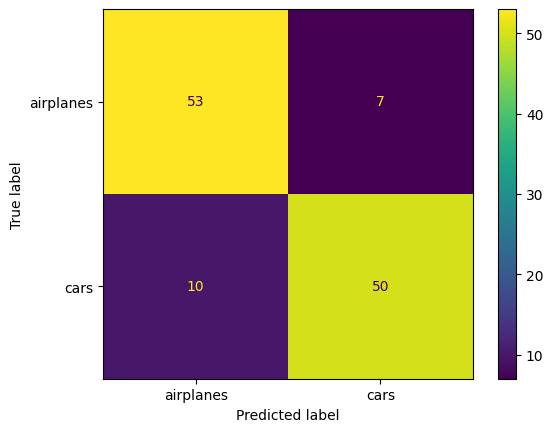

In [56]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# TODO: TP, TN, FP, FN 계산

TP = TN = FP = FN = 0

#실제 레이블인 y_test와 예측 레이블인 y_pred를 순회하면서 TP, TF, FP, FN 카운트
#t = 실제, pred = 예측
for i, t in enumerate(y_test):
    pred = y_pred[i]
    if t == 1 and pred == 1:
        TP += 1
    elif t == 0 and pred == 0:
        TN += 1
    elif t == 0 and pred == 1:
        FP += 1
    elif t == 1 and pred == 0:
        FN += 1


print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

# TODO: TP, TN, FP, FN을 사용하여 Accuracy, Precision, Recall 계산
#accuracy: 전체 예측 중 올바르게 예측한 비율
accuracy  = (TP + TN) / len(y_test)
#precision: 모델이 positive로 예측한 것 중 실제 맞춘 비율
precision = TP / (TP + FP)
#recall: 실제 positive 중에서 모델이 올바르게 찾아낸 비율
recall = TP / (TP + FN)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot()
